In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from math import sqrt
import matplotlib.pyplot as plt
import matplotlib.pyplot as pyplot
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
import xgboost as xgb
import statistics as stats
import statsmodels.api as sm
import shap
from matplotlib.dates import DateFormatter
from xgboost import plot_importance, plot_tree, XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.tsa.stattools import adfuller

In [ ]:
!pip install pmdarima
from pmdarima.arima import ndiffs

# *Preprocessing* Data

In [ ]:
# Input Data
data = pd.read_csv('/content/Skripsi_Fellita Odelia Wibowo.csv')
data

,Bulan,Suhu,DPM Rata-rata,DPM Maksimum,DPM Minimum
0,01 1999,24.177419,30092.61419,40613.36,9725.40
1,02 1999,23.971429,33898.16893,40363.34,8823.81
2,03 1999,24.280645,32010.34290,40334.69,1194.58
3,04 1999,24.133333,36139.28767,39600.00,19013.41
4,05 1999,23.590323,38292.59323,39589.61,27711.09
...,...,...,...,...,...
313,02 2025,24.460714,35262.12000,41519.75,12301.87
314,03 2025,24.954839,33148.25742,41275.54,18045.26
315,04 2025,24.763333,35864.13900,39617.05,23049.29
316,05 2025,25.351613,33211.00806,39594.77,18897.02


In [ ]:
# Menyiapkan Data
data = data.set_index('Bulan')
data.index = pd.to_datetime(data.index, format = ' %m %Y')

In [ ]:
# Menampilkan 5 Baris Pertama
print(data.head())

                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
1999-01-01  24.177419    30092.61419      40613.36      9725.40
1999-02-01  23.971429    33898.16893      40363.34      8823.81
1999-03-01  24.280645    32010.34290      40334.69      1194.58
1999-04-01  24.133333    36139.28767      39600.00     19013.41
1999-05-01  23.590323    38292.59323      39589.61     27711.09


In [ ]:
# Menampilkan Informasi Data
print(data.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 318 entries, 1999-01-01 to 2025-06-01
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suhu           318 non-null    float64
 1   DPM Rata-rata  318 non-null    float64
 2   DPM Maksimum   318 non-null    float64
 3   DPM Minimum    318 non-null    float64
dtypes: float64(4)
memory usage: 12.4 KB
None


In [ ]:
# Mendefinisikan Variabel
Suhu = data['Suhu']
DPM_mean = data['DPM Rata-rata']
DPM_max = data['DPM Maksimum']
DPM_min = data['DPM Minimum']

# Visualisasi Data

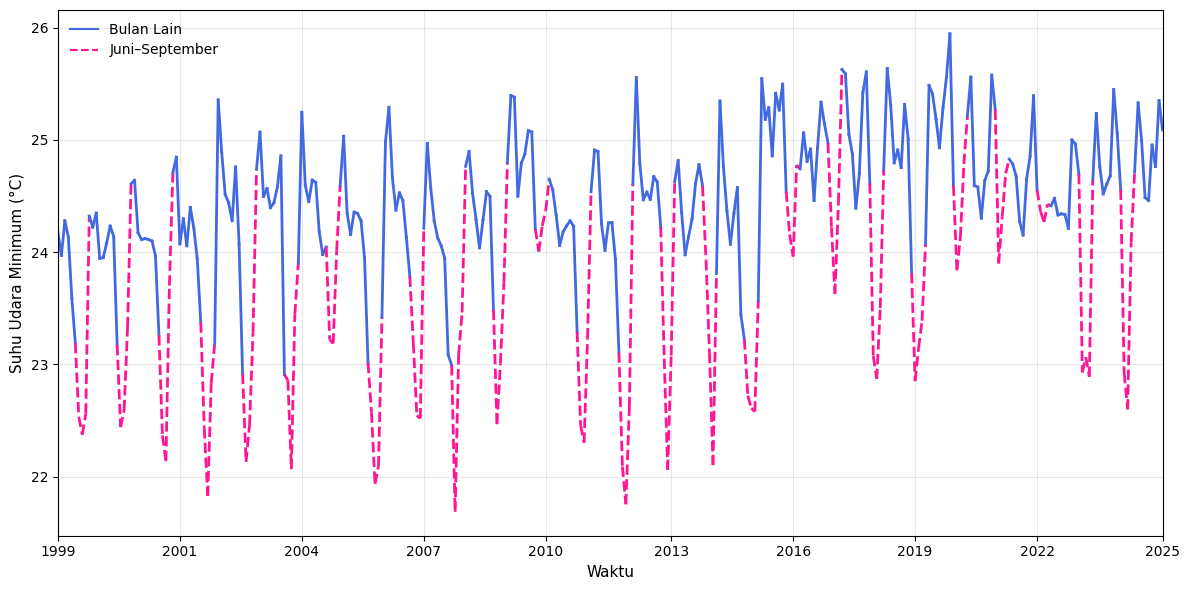

In [ ]:
# Plot Data Suhu (Highlight Bulan Juni-September)
x = np.arange(len(Suhu))
y = Suhu.values.flatten()
bulan = Suhu.index.month

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis = 1)

colors = ['deeppink' if m in [6, 7, 8, 9] else 'royalblue' for m in bulan[:-1]]
linestyles = ['--' if m in [6, 7, 8, 9] else '-' for m in bulan[:-1]]

fig, ax = plt.subplots(figsize = (12, 6))
for seg, c, ls in zip(segments, colors, linestyles):
    ax.plot(seg[:,0], seg[:,1], color = c, linestyle = ls, linewidth = 2)

ax.set_xlim(x.min(), x.max())
ax.set_xlabel("Waktu", fontsize = 11)
ax.set_ylabel("Suhu Udara Minimum (°C)", fontsize = 11)

xticks = np.linspace(0, len(Suhu)-1, 10, dtype = int)
ax.set_xticks(xticks)
ax.set_xticklabels(pd.to_datetime(Suhu.index[xticks]).year, rotation = 0)

ax.grid(alpha = 0.3)
ax.plot([], [], color = 'royalblue', linestyle = '-', label = 'Bulan Lain')
ax.plot([], [], color = 'deeppink', linestyle = '--', label = 'Juni–September')
ax.legend(loc = 'upper left', frameon = False)

plt.tight_layout()
plt.show()

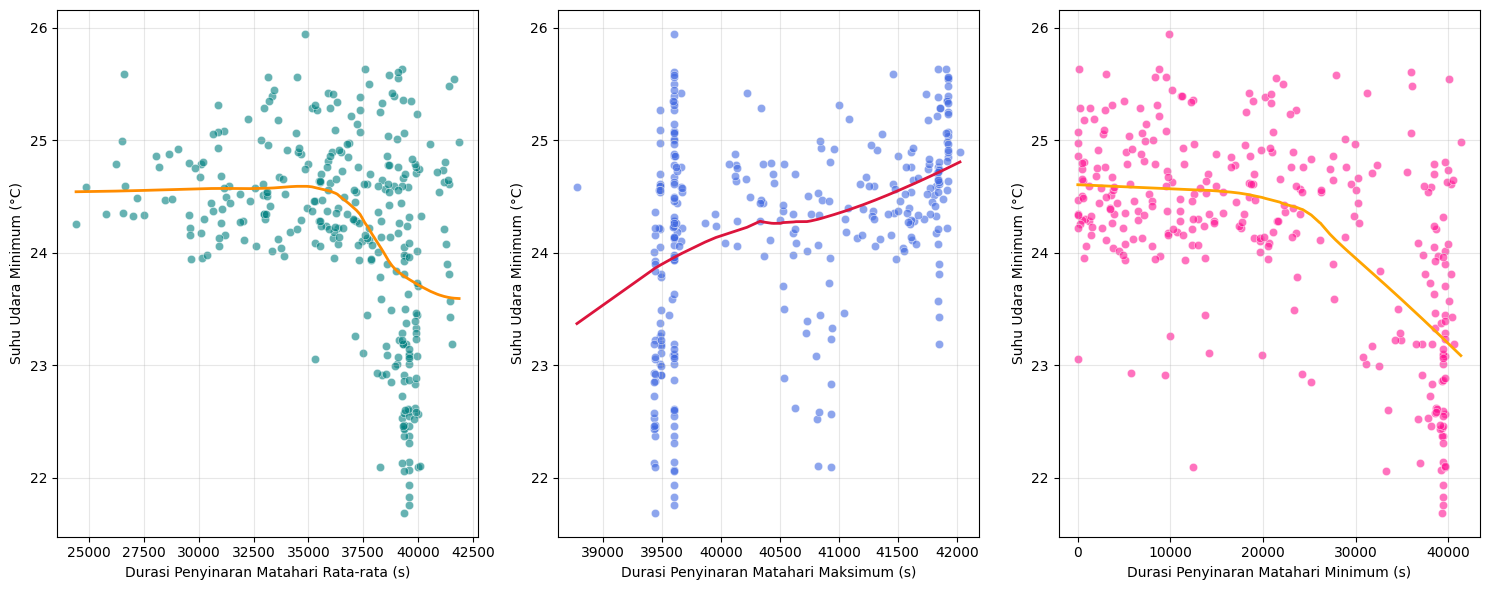

In [ ]:
# Plot Durasi Penyinaran Matahari dengan Suhu
plt.figure(figsize = (15, 6))

plt.subplot(1, 3, 1)
sns.scatterplot(x = 'DPM Rata-rata', y = 'Suhu', data = data,
                color = 'teal', alpha = 0.6)
sns.regplot(x = 'DPM Rata-rata', y = 'Suhu', data = data,
            scatter = False, lowess = True, color = 'darkorange', line_kws = {'linewidth': 2})
plt.xlabel('Durasi Penyinaran Matahari Rata-rata (s)')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.grid(alpha = 0.3)

plt.subplot(1, 3, 2)
sns.scatterplot(x = 'DPM Maksimum', y = 'Suhu', data = data,
                color = 'royalblue', alpha = 0.6)
sns.regplot(x = 'DPM Maksimum', y = 'Suhu', data = data,
            scatter = False, lowess = True, color = 'crimson', line_kws = {'linewidth': 2})
plt.xlabel('Durasi Penyinaran Matahari Maksimum (s)')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.grid(alpha = 0.3)

plt.subplot(1, 3, 3)
sns.scatterplot(x = 'DPM Minimum', y = 'Suhu', data = data,
                color = 'deeppink', alpha = 0.6)
sns.regplot(x = 'DPM Minimum', y = 'Suhu', data = data,
            scatter = False, lowess = True, color = 'orange', line_kws = {'linewidth': 2})
plt.xlabel('Durasi Penyinaran Matahari Minimum (s)')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

# Karakteristik Data

In [ ]:
# Uji Stasioneritas (Uji Augmented Dickey-Fuller, ADF)
adf_result = adfuller(Suhu.dropna(), maxlag = 6, autolag = None)

print(f"ADF Statistic : {adf_result[0]}")
print(f"p-value       : {adf_result[1]}")
print(f"Lag used      : {adf_result[2]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key} : {value}")

if adf_result[1] < 0.05:
    print("Tolak H0: Data Stasioner")
else:
    print("Terima H0: Data Tidak Stasioner")

ADF Statistic : -7.535272941262401
p-value       : 3.491809089335152e-11
Lag used      : 6
Critical Values:
   1% : -3.451552879535732
   5% : -2.8708786756338407
   10% : -2.571745666091128
Tolak H0: Data Stasioner


In [ ]:
# Penentuan Orde Differencing (d)
d = ndiffs(Suhu, test = 'adf')
print("Nilai d:", d)

Nilai d: 0


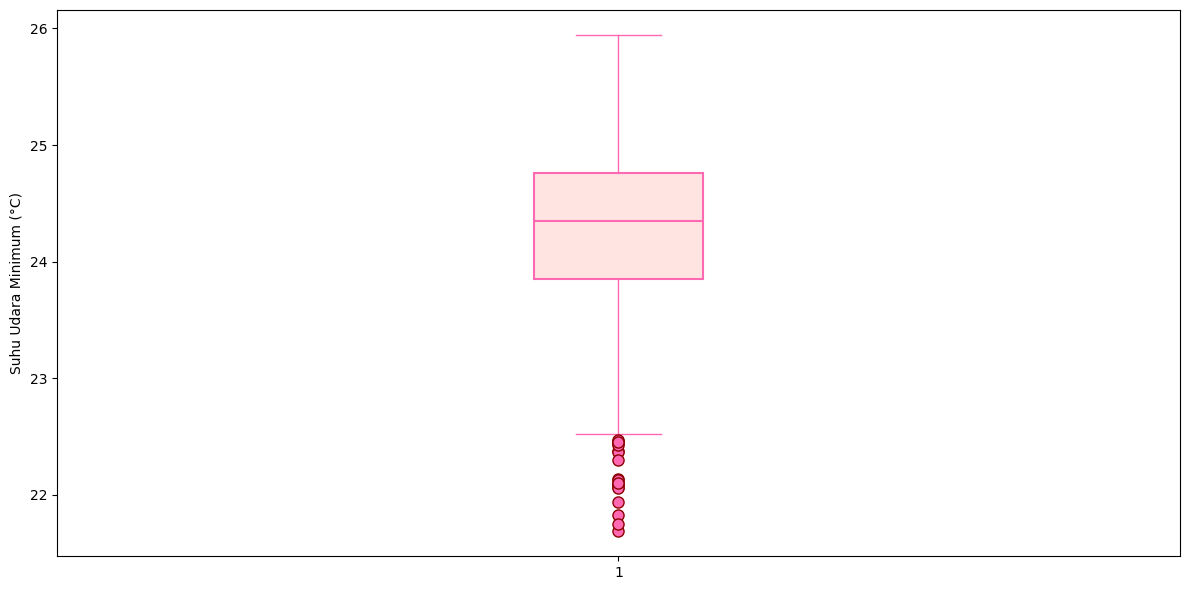

In [ ]:
# Boxplot
plt.figure(figsize = (12, 6), facecolor = 'white')

box = plt.boxplot(Suhu, patch_artist = True,
                  boxprops = dict(facecolor = 'mistyrose',
                              color = 'hotpink',
                              linewidth = 1.5),
                  whiskerprops = dict(color = 'hotpink', linewidth = 1),
                  capprops = dict(color = 'hotpink', linewidth = 1),
                  medianprops = dict(color = 'hotpink', linewidth = 1.5),
                  flierprops = dict(marker = 'o',
                                markerfacecolor = 'hotpink',
                                markeredgecolor = 'darkred',
                                markeredgewidth = 1,
                                markersize = 8))

plt.ylabel("Suhu Udara Minimum (°C)")
plt.tight_layout()
plt.show()

In [ ]:
# Mendeteksi Outliers
Q1_suhu = Suhu.quantile(0.25)
Q3_suhu = Suhu.quantile(0.75)
IQR_suhu = Q3_suhu - Q1_suhu
lower_bound_suhu = Q1_suhu - 1.5 * IQR_suhu
upper_bound_suhu = Q3_suhu + 1.5 * IQR_suhu
outliers_suhu = Suhu[(Suhu < lower_bound_suhu) | (Suhu > upper_bound_suhu)]
print("Outliers:\n", outliers_suhu)

Outliers:
 Bulan
1999-08-01    22.374194
2000-07-01    22.441935
2001-07-01    22.367742
2001-08-01    22.138710
2002-07-01    22.432258
2002-08-01    21.829032
2003-07-01    22.132258
2003-08-01    22.461290
2004-08-01    22.067742
2006-08-01    21.935484
2006-09-01    22.093333
2008-07-01    21.687097
2009-07-01    22.467742
2011-07-01    22.458065
2011-08-01    22.303226
2012-07-01    22.090323
2012-08-01    21.754839
2013-08-01    22.061290
2014-09-01    22.103333
Name: Suhu, dtype: float64


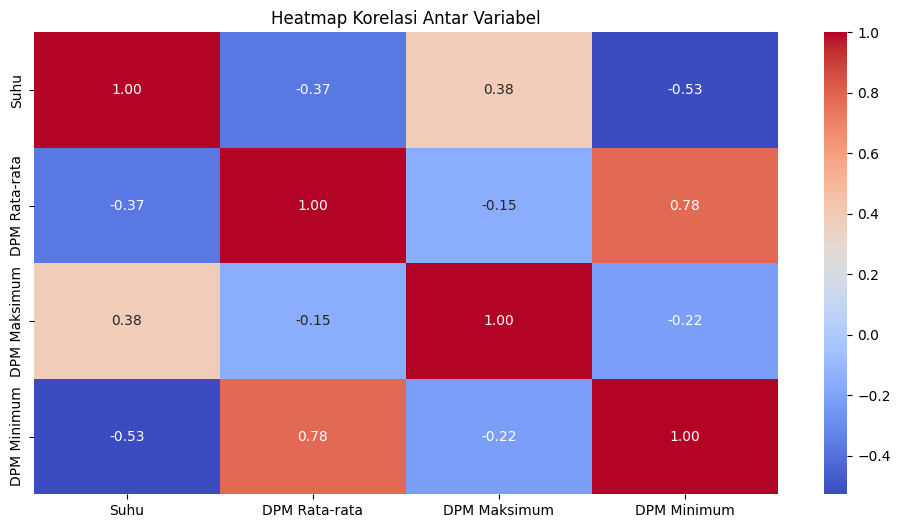

In [ ]:
# Mengidentifikasi Korelasi Antar Variabel
corr_matrix = data.corr()
plt.figure(figsize = (12, 6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

# Model XGBoost

In [ ]:
# Fitur Time Series
def create_features(data, target, lag_features, exog_features, lag_exogs, rolling_windows):
    # Salinan DataFrame (menghindari modifikasi data asli)
    data_features = data.copy()
    # Date-Time
    data_features['month'] = data_features.index.month
    data_features['year'] = data_features.index.year
    # Lag Features untuk Variabel Target (berbasis bulanan)
    for lag in lag_features:
        data_features[f'{target}_lag_{lag}'] = data_features[target].shift(lag)
    # Lag Features untuk Variabel Eksogen (berbasis bulanan)
    for feature in exog_features:
        for lag in lag_exogs:
            data_features[f'{feature}_lag_{lag}'] = data_features[feature].shift(lag)
    # Rolling Windows
    for col in data.columns:
        for window in rolling_windows:
            data_features[f'{col}_mean_{window}'] = data_features[col].rolling(window = window).mean()
            data_features[f'{col}_std_{window}'] = data_features[col].rolling(window = window).std()
    # Cyclical Encoding
    data_features['month_sin'] = np.sin(2 * np.pi * data_features['month']/12)
    data_features['month_cos'] = np.cos(2 * np.pi * data_features['month']/12)

    # Hapus baris dengan nilai NaN (yang dihasilkan dari shift dan rolling)
    data_features.dropna(inplace = True)

    return data_features

In [ ]:
# Split Data Asli Train & Test
split_ratio = 0.8
split_index = int(len(data) * split_ratio)

train_original = data.iloc[:split_index].copy()
test_original = data.iloc[split_index:].copy()

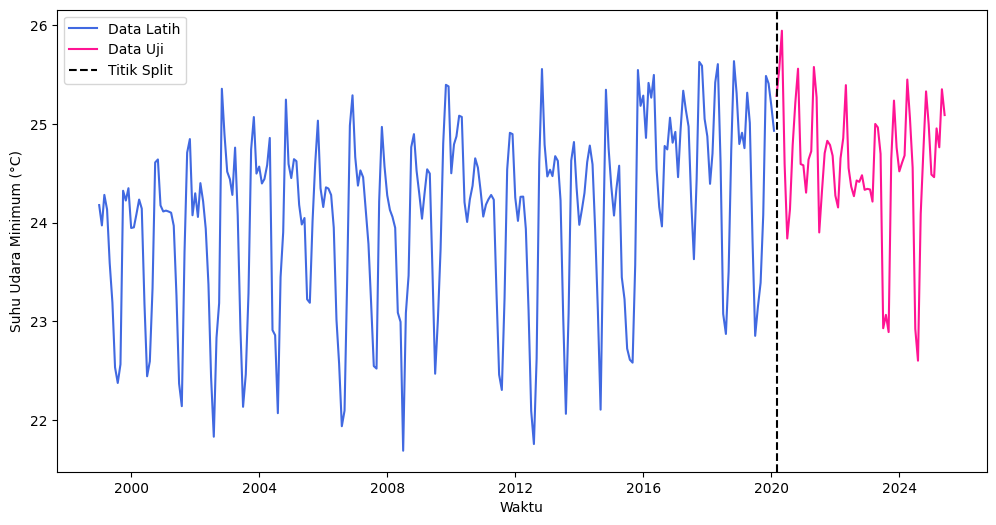

In [ ]:
# Visualisasi Split Data
plt.figure(figsize = (12, 6))

plt.plot(train_original.index,
         train_original.iloc[:, 0],
         label = "Data Latih",
         color = "royalblue")

plt.plot(test_original.index,
         test_original.iloc[:, 0],
         label = "Data Uji",
         color = "deeppink")

plt.axvline(x = data.index[split_index],
            linestyle = '--',
            color = 'black',
            label = "Titik Split")

plt.xlabel("Waktu")
plt.ylabel("Suhu Udara Minimum (°C)")
plt.legend()
plt.show()

In [ ]:
# Mendefinisikan Fitur
target = 'Suhu'
lag_features = [6, 12, 24]
exog_features = ['DPM Rata-rata', 'DPM Maksimum', 'DPM Minimum']
lag_exogs = [6, 12, 24]
rolling_windows = [6, 12, 24]

In [ ]:
# Split Data Hasil Feature Engineering Train & Test
train_processed = create_features(train_original, target, lag_features, exog_features, lag_exogs, rolling_windows)
test_processed = create_features(test_original, target, lag_features, exog_features, lag_exogs, rolling_windows)

X_train = train_processed.drop(target, axis = 1)
y_train = train_processed[target]

X_test = test_processed.drop(target, axis = 1)
y_test = test_processed[target]

print("Data Training (setelah pembuatan fitur):")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nData Testing (setelah pembuatan fitur):")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print("\nContoh data training:")
print(X_train.head())
print("\nContoh data testing:")
print(X_test.head())

Data Training (setelah pembuatan fitur):
X_train: (230, 43)
y_train: (230,)

Data Testing (setelah pembuatan fitur):
X_test: (40, 43)
y_test: (40,)

Contoh data training:
            DPM Rata-rata  DPM Maksimum  DPM Minimum  month  year  Suhu_lag_6  \
Bulan                                                                           
2001-01-01    32076.90710      41617.50      3092.91      1  2001   22.441935   
2001-02-01    33610.04786      41350.23      5933.42      2  2001   22.593548   
2001-03-01    37763.24710      40416.04     26104.59      3  2001   23.333333   
2001-04-01    37431.32900      39665.16     19680.31      4  2001   24.609677   
2001-05-01    39444.25129      39600.00     38925.20      5  2001   24.640000   

            Suhu_lag_12  Suhu_lag_24  DPM Rata-rata_lag_6  \
Bulan                                                       
2001-01-01    23.945161    24.177419          39366.34548   
2001-02-01    23.951724    23.971429          39577.01871   
2001-03-01    24.

In [ ]:
# Mengidentifikasi Parameter Terbaik
tss = TimeSeriesSplit(n_splits = 5)

reg = xgb.XGBRegressor(objective = 'reg:squarederror', eval_metric = 'rmse', use_label_encoder = False, n_jobs = -1)

parameters = {
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [200, 300],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
    "min_child_weight": [5, 10],
    "gamma": [1, 5],
    "reg_alpha": [2, 5],
    "reg_lambda": [5, 10]
    }

In [ ]:
# Menjalankan Model
grid_search = GridSearchCV(estimator = reg, param_grid = parameters, cv = tss, scoring = 'neg_mean_squared_error', verbose = 1, n_jobs = -1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:11:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False,
                                    eval_metric='rmse', feature_types=None,
                                    feature_weights=None, gamma=No...
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.7, 0.8], 'gamma': [1, 5],
                         'learning_rate': [0.01, 0.05], 'max_depth': [3, 5],
                         'min_child_weight': [5, 10],
                         'n_estimators': [200, 300], 'reg_alpha': [2, 5],
                         'reg_lambda': [5, 10], 'subsample': [0.7, 0.8]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
# Menampilkan Model Terbaik
print("Parameter Terbaik:")
best_params = grid_search.best_params_
print(best_params)

print("\nSkor terbaik (Negated MSE):")
best_score = grid_search.best_score_
print(best_score)

Parameter Terbaik:
{'colsample_bytree': 0.7, 'gamma': 1, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 300, 'reg_alpha': 2, 'reg_lambda': 5, 'subsample': 0.8}

Skor terbaik (Negated MSE):
-0.35340648907229644


In [ ]:
# Model Data Train dengan Parameter Terbaik
final_model = xgb.XGBRegressor(**best_params, n_jobs = -1, objective = 'reg:squarederror')
final_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Membuat Prediksi pada Data Training
y_train_pred = final_model.predict(X_train)

In [ ]:
# Membuat Prediksi pada Data Testing
y_test_pred = final_model.predict(X_test)

# Feature Importance

In [ ]:
# Feature Importance dari Model
importance = final_model.feature_importances_
feature_names = X_train.columns

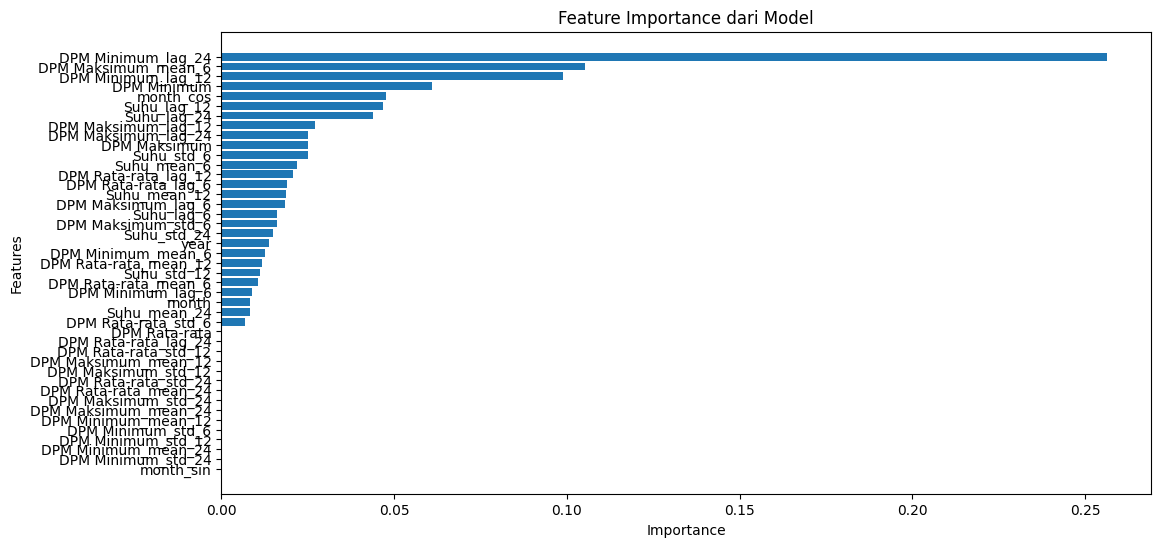

In [ ]:
# Visualisasi Feature Importance dari Model
feature_importance_data = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance_data = feature_importance_data.sort_values(by = 'importance', ascending = False)

plt.figure(figsize = (12, 6))
plt.barh(feature_importance_data['feature'], feature_importance_data['importance'])
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance dari Model')
plt.gca().invert_yaxis()
plt.show()

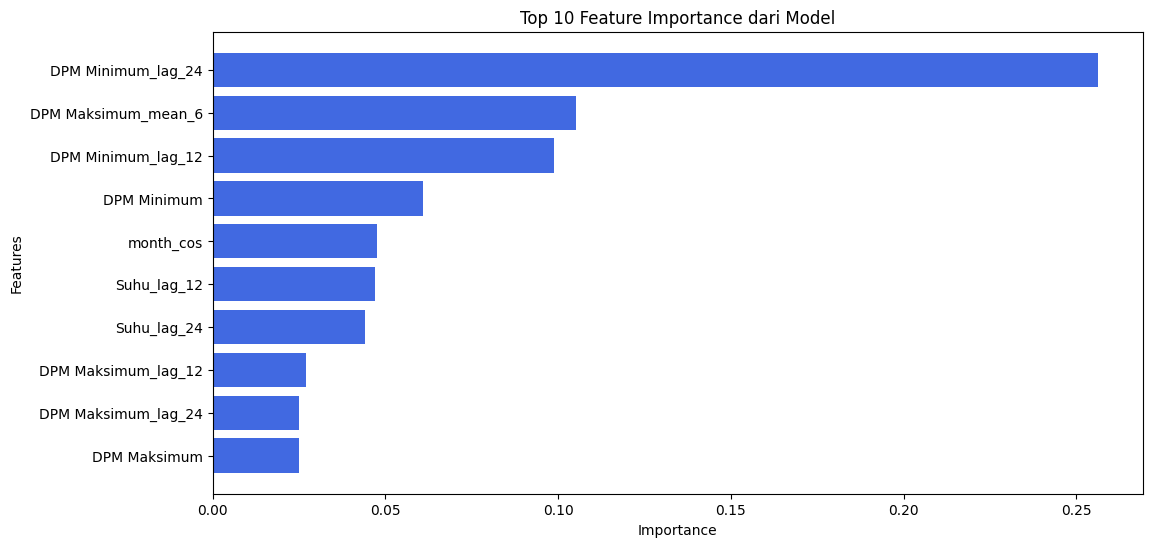

In [ ]:
# Visualisasi Feature Importance dari Model (10 Teratas)
feature_importance_data = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance_data = feature_importance_data.sort_values(by = 'importance', ascending = False)

top_10_features = feature_importance_data.head(10)

plt.figure(figsize = (12, 6))
plt.barh(top_10_features['feature'], top_10_features['importance'], color = 'royalblue')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Top 10 Feature Importance dari Model')
plt.gca().invert_yaxis()
plt.show()

# Evaluasi Model

In [ ]:
# Fungsi MAPE
def mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    ape = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(ape) * 100

    return mape

In [ ]:
# Fungsi SMAPE
def symmetric_mean_absolute_percentage_error(y_true, y_pred):

    y_true, y_pred = np.array(y_true), np.array(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred))/2
    smape = np.mean(np.abs(y_true - y_pred)/denominator) * 100
    return smape

In [ ]:
# Evaluasi pada Data Training
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
smape_train = symmetric_mean_absolute_percentage_error(y_train, y_train_pred)

print("Evaluasi pada Data Training:")
print(f"MSE: {mse_train:.3f}")
print(f"RMSE: {rmse_train:.3f}")
print(f"MAPE: {mape_train:.3f}%")
print(f"SMAPE: {smape_train:.3f}%")

Evaluasi pada Data Training:
MSE: 0.100
RMSE: 0.316
MAPE: 1.022%
SMAPE: 1.021%


In [ ]:
# Evaluasi pada Data Testing
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
smape_test = symmetric_mean_absolute_percentage_error(y_test, y_test_pred)

print("Evaluasi pada Data Testing:")
print(f"MSE: {mse_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"MAPE: {mape_test:.3f}%")
print(f"SMAPE: {smape_test:.3f}%")

Evaluasi pada Data Testing:
MSE: 0.145
RMSE: 0.381
MAPE: 1.251%
SMAPE: 1.253%


# Analisis SHAP (TreeSHAP)

In [ ]:
# Explainer SHAP
explainer = shap.TreeExplainer(final_model)

In [ ]:
# Nilai SHAP pada Semua Data Test
shap_values_all = explainer.shap_values(X_test)

shap_values_all_df = pd.DataFrame(shap_values_all, columns = X_test.columns)
shap_values_all_df

,DPM Rata-rata,DPM Maksimum,DPM Minimum,month,year,Suhu_lag_6,Suhu_lag_12,Suhu_lag_24,DPM Rata-rata_lag_6,DPM Rata-rata_lag_12,...,DPM Maksimum_mean_24,DPM Maksimum_std_24,DPM Minimum_mean_6,DPM Minimum_std_6,DPM Minimum_mean_12,DPM Minimum_std_12,DPM Minimum_mean_24,DPM Minimum_std_24,month_sin,month_cos
0,0.0,0.017672,0.045769,-0.023740,0.134860,0.029106,0.042994,0.014218,0.023520,0.016196,...,0.0,0.0,-0.003742,0.0,0.0,0.0,0.0,0.0,0.0,0.002480
1,0.0,0.012520,0.042854,-0.000995,0.134860,0.029106,0.045489,0.014218,0.023520,0.016196,...,0.0,0.0,-0.003742,0.0,0.0,0.0,0.0,0.0,0.0,0.002480
2,0.0,0.015188,0.044777,0.005131,0.128340,0.036950,0.164357,0.014218,-0.064920,-0.032446,...,0.0,0.0,-0.003742,0.0,0.0,0.0,0.0,0.0,0.0,-0.027169
3,0.0,-0.243806,0.044376,0.003605,0.091810,0.036950,0.144285,0.014929,-0.064920,0.030614,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,-0.027169
4,0.0,-0.164607,0.052534,-0.000454,0.068758,-0.033414,-0.075541,-0.013501,-0.072253,-0.027390,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,-0.008074
5,0.0,0.001307,0.032611,0.004543,0.069305,-0.026731,0.043039,-0.006799,-0.072253,-0.027390,...,0.0,0.0,0.000596,0.0,0.0,0.0,0.0,0.0,0.0,0.002096
6,0.0,0.005509,0.051136,0.014152,0.083704,0.061161,0.044266,0.014218,-0.018226,-0.004702,...,0.0,0.0,0.000596,0.0,0.0,0.0,0.0,0.0,0.0,0.002096
7,0.0,0.052944,0.049306,0.031076,0.114582,0.036678,0.119566,0.014218,-0.003532,-0.021704,...,0.0,0.0,0.000596,0.0,0.0,0.0,0.0,0.0,0.0,0.002594
8,0.0,0.127188,0.042035,0.035136,0.108377,0.033159,0.093059,0.014218,-0.068290,0.016449,...,0.0,0.0,0.000568,0.0,0.0,0.0,0.0,0.0,0.0,0.004331
9,0.0,0.040321,0.043712,0.039903,0.129463,-0.012574,0.051833,0.011888,0.026082,0.018181,...,0.0,0.0,-0.003742,0.0,0.0,0.0,0.0,0.0,0.0,0.002480


In [ ]:
# Ranking Fitur Global
mean_abs_shap_all = np.abs(shap_values_all).mean(axis = 0)

feature_importance_all = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': mean_abs_shap_all
}).sort_values(by = 'mean_abs_shap', ascending = False)

print("Ranking Fitur (Global):")
print(feature_importance_all)

Ranking Fitur (Global):
                  feature  mean_abs_shap
29    DPM Maksimum_mean_6       0.192406
17            Suhu_mean_6       0.127126
4                    year       0.108491
6             Suhu_lag_12       0.089019
15     DPM Minimum_lag_12       0.064492
1            DPM Maksimum       0.063819
2             DPM Minimum       0.061037
19           Suhu_mean_12       0.047390
18             Suhu_std_6       0.047015
8     DPM Rata-rata_lag_6       0.043543
5              Suhu_lag_6       0.028439
23   DPM Rata-rata_mean_6       0.027193
12    DPM Maksimum_lag_12       0.024790
9    DPM Rata-rata_lag_12       0.021641
3                   month       0.016470
13    DPM Maksimum_lag_24       0.015386
7             Suhu_lag_24       0.012441
20            Suhu_std_12       0.009903
11     DPM Maksimum_lag_6       0.009315
16     DPM Minimum_lag_24       0.008725
42              month_cos       0.008410
25  DPM Rata-rata_mean_12       0.006939
30     DPM Maksimum_std_6       0

In [ ]:
# Filter Data Bulan Juni-September
X_test_js = X_test[X_test['month'].isin([6, 7, 8, 9])]
shap_values_js = explainer.shap_values(X_test_js)

In [ ]:
# 5 Fitur Teratas
top5_features = feature_importance_all.head(5)['feature'].tolist()
print("5 Fitur Teratas Global:", top5_features)

5 Fitur Teratas Global: ['DPM Maksimum_mean_6', 'Suhu_mean_6', 'year', 'Suhu_lag_12', 'DPM Minimum_lag_12']


In [ ]:
# Nilai SHAP pada Bulan Juni–September
shap_values_js_df = pd.DataFrame(shap_values_js, columns = X_test_js.columns)
shap_values_js_df

,DPM Rata-rata,DPM Maksimum,DPM Minimum,month,year,Suhu_lag_6,Suhu_lag_12,Suhu_lag_24,DPM Rata-rata_lag_6,DPM Rata-rata_lag_12,...,DPM Maksimum_mean_24,DPM Maksimum_std_24,DPM Minimum_mean_6,DPM Minimum_std_6,DPM Minimum_mean_12,DPM Minimum_std_12,DPM Minimum_mean_24,DPM Minimum_std_24,month_sin,month_cos
0,0.0,-0.243806,0.044376,0.003605,0.091810,0.036950,0.144285,0.014929,-0.064920,0.030614,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,-0.027169
1,0.0,-0.164607,0.052534,-0.000454,0.068758,-0.033414,-0.075541,-0.013501,-0.072253,-0.027390,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,-0.008074
2,0.0,0.001307,0.032611,0.004543,0.069305,-0.026731,0.043039,-0.006799,-0.072253,-0.027390,...,0.0,0.0,0.000596,0.0,0.0,0.0,0.0,0.0,0.0,0.002096
3,0.0,0.005509,0.051136,0.014152,0.083704,0.061161,0.044266,0.014218,-0.018226,-0.004702,...,0.0,0.0,0.000596,0.0,0.0,0.0,0.0,0.0,0.0,0.002096
4,0.0,-0.221770,-0.095974,0.005083,0.086925,-0.018174,0.078422,0.022798,-0.072253,0.026705,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,-0.020037
5,0.0,-0.168203,0.052852,-0.002421,0.068758,-0.026731,0.055173,-0.014154,-0.074595,-0.010646,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,-0.008074
6,0.0,-0.006408,-0.128548,0.008714,0.070806,-0.026731,0.031428,-0.005757,-0.081019,-0.031772,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,0.002096
7,0.0,0.001251,-0.136824,0.011725,0.077564,-0.026731,0.060903,0.022107,-0.040667,-0.024292,...,0.0,0.0,0.000596,0.0,0.0,0.0,0.0,0.0,0.0,0.002096
8,0.0,-0.195095,0.051131,-0.002290,0.092653,0.029106,0.066233,0.014673,0.023520,-0.028536,...,0.0,0.0,-0.001755,0.0,0.0,0.0,0.0,0.0,0.0,-0.020037
9,0.0,-0.159318,0.049632,-0.000454,0.061042,-0.037216,-0.172441,0.008766,-0.079843,-0.010646,...,0.0,0.0,0.000596,0.0,0.0,0.0,0.0,0.0,0.0,-0.008074


In [ ]:
# Rata-rata Nilai SHAP (Juni-September)
mean_shap_js_signed = shap_values_js.mean(axis = 0)

mean_abs_shap_js = np.abs(mean_shap_js_signed) # nilai absolutnya untuk ranking

shap_js_df = pd.DataFrame({
    'feature': X_test_js.columns,
    'mean_SHAP_signed_JS': mean_shap_js_signed,
    'abs_SHAP': mean_abs_shap_js
})

shap_js_top5 = shap_js_df[shap_js_df['feature'].isin(top5_features)] # filter 5 fitur global
shap_js_top5 = shap_js_top5.sort_values(by = 'abs_SHAP', ascending = False) # urutkan berdasarkan absolut

shap_js_top5[['feature','mean_SHAP_signed_JS']].style.format({
    'mean_SHAP_signed_JS': "{:.3f}"
})

,feature,mean_SHAP_signed_JS
29,DPM Maksimum_mean_6,-0.270
17,Suhu_mean_6,0.108
4,year,0.075
15,DPM Minimum_lag_12,-0.014
6,Suhu_lag_12,0.001


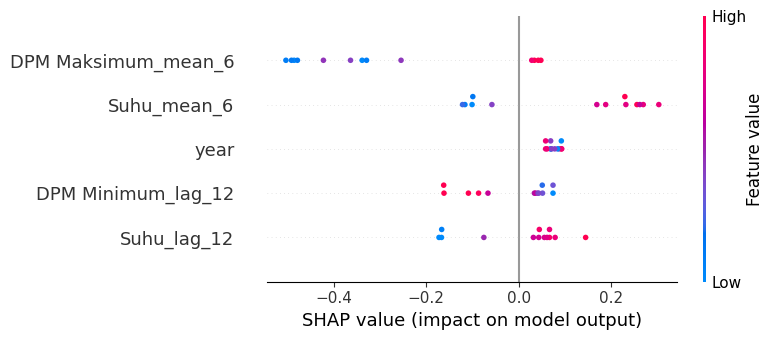

In [ ]:
# Visualisasi Nilai SHAP Bulan Juni–September (Beeswarm Plot)
mean_shap_js_signed = shap_values_js.mean(axis = 0)

shap_js_df = pd.DataFrame({
    'feature': X_test_js.columns,
    'mean_SHAP_signed_JS': mean_shap_js_signed
})

shap_js_top5 = shap_js_df[shap_js_df['feature'].isin(top5_features)].copy()

shap_js_top5['abs_SHAP'] = shap_js_top5['mean_SHAP_signed_JS'].abs()
shap_js_top5 = shap_js_top5.sort_values(by = 'abs_SHAP', ascending = False)

ordered_features = shap_js_top5['feature'].tolist() # urutan fitur sesuai tabel final

X_test_js_top5 = X_test_js[ordered_features] # subset data dan SHAP sesuai urutan tersebut
top5_indices = [X_test_js.columns.get_loc(f) for f in ordered_features]
shap_values_js_top5 = shap_values_js[:, top5_indices]

shap.summary_plot( # beeswarm plot
    shap_values_js_top5,
    X_test_js_top5,
    sort = False
)

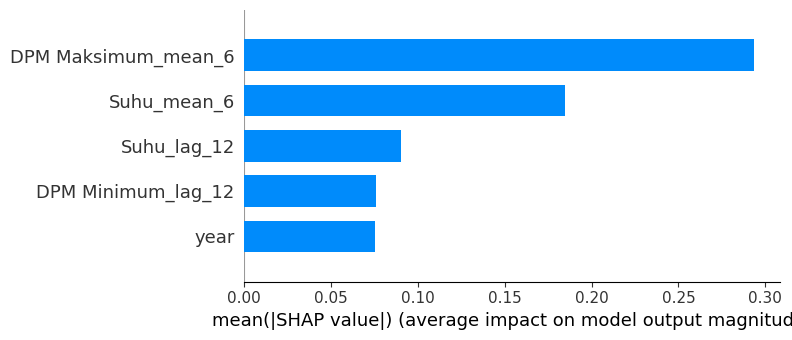

In [ ]:
# Visualisasi Nilai SHAP Bulan Juni–September (Bar Plot Importance)
shap.summary_plot(shap_values_js_top5, X_test_js_top5, plot_type = "bar")

# Data Aktual vs Prediksi

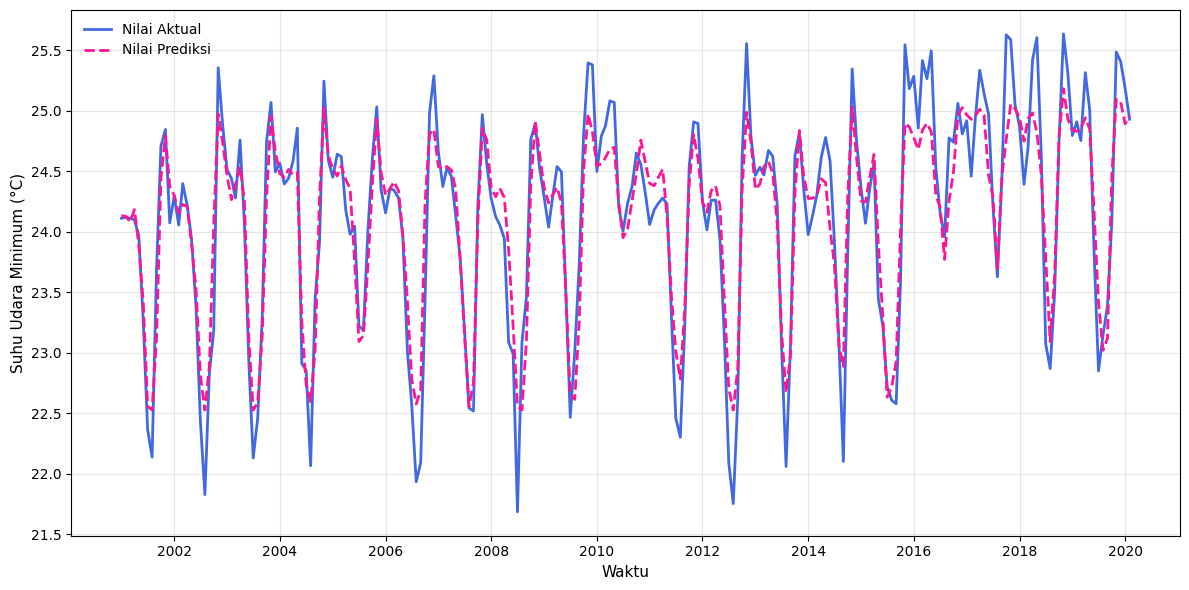

In [ ]:
# Visualisasi Data Train Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train,
    'prediksi': y_train_pred
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Suhu Udara Minimum (°C)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

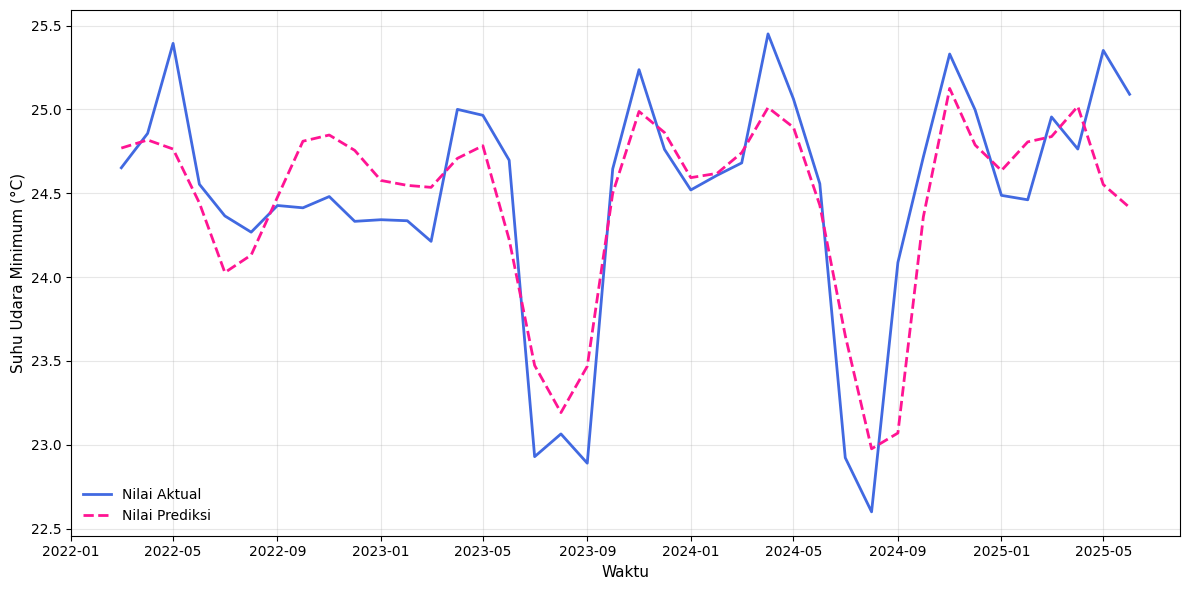

In [ ]:
# Visualisasi Data Test Aktual vs Prediksi
hasil_test = pd.DataFrame({
    'aktual': y_test,
    'prediksi': y_test_pred
})

plt.figure(figsize = (12, 6))

plt.plot(
    hasil_test.index,
    hasil_test['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    hasil_test.index,
    hasil_test['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.xlabel('Waktu', fontsize = 11)
plt.ylabel('Suhu Udara Minimum (°C)', fontsize = 11)

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

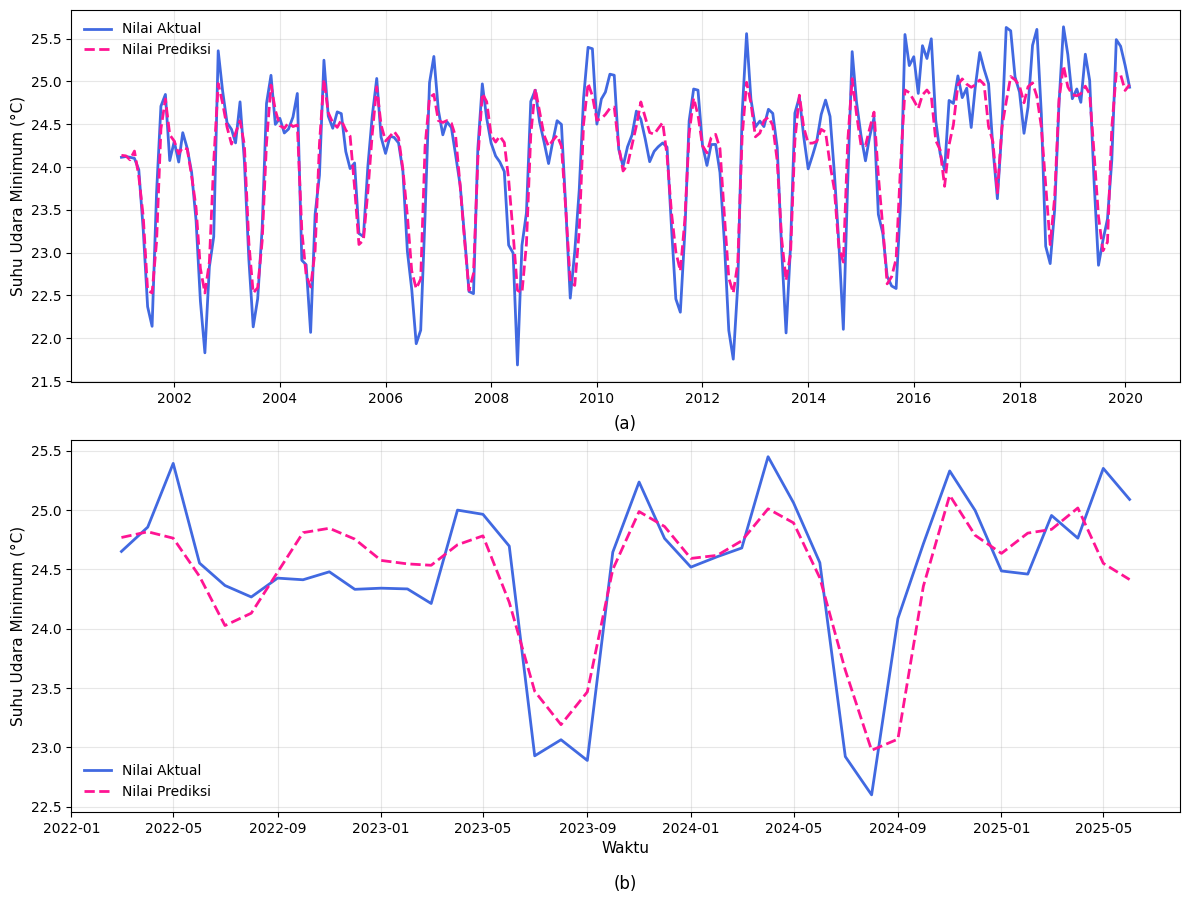

In [ ]:
# Visualisasi Data Train & Test Aktual vs Prediksi
hasil_train = pd.DataFrame({
    'aktual': y_train,
    'prediksi': y_train_pred
})

hasil_test = pd.DataFrame({
    'aktual': y_test,
    'prediksi': y_test_pred
})

fig, axes = plt.subplots(2, 1, figsize = (12, 9))

axes[0].plot(
    hasil_train.index,
    hasil_train['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[0].plot(
    hasil_train.index,
    hasil_train['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

axes[0].set_ylabel('Suhu Udara Minimum (°C)', fontsize = 11)
axes[0].set_title("(a)", y = -0.15)
axes[0].legend(frameon = False)
axes[0].grid(alpha = 0.3)

axes[1].plot(
    hasil_test.index,
    hasil_test['aktual'],
    label = 'Nilai Aktual',
    color = 'royalblue',
    linewidth = 2
)

axes[1].plot(
    hasil_test.index,
    hasil_test['prediksi'],
    label = 'Nilai Prediksi',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

axes[1].set_xlabel('Waktu', fontsize = 11)
axes[1].set_ylabel('Suhu Udara Minimum (°C)', fontsize = 11)
axes[1].set_title("(b)", y = -0.23)
axes[1].legend(frameon = False)
axes[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Data Train Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_train, prediksi_train in zip(y_train, y_train_pred):
    selisih_train = aktual_train - prediksi_train
    print(f"  {aktual_train:.3f}         {prediksi_train:.3f}            {selisih_train:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  24.113         24.135            -0.022
  24.121         24.129            -0.008
  24.113         24.084            0.029
  24.100         24.185            -0.085
  23.968         23.892            0.076
  23.260         23.415            -0.155
  22.368         22.559            -0.191
  22.139         22.528            -0.389
  23.703         23.129            0.574
  24.710         24.444            0.266
  24.847         24.794            0.053
  24.074         24.375            -0.301
  24.297         24.303            -0.006
  24.057         24.154            -0.097
  24.400         24.227            0.173
  24.217         24.209            0.008
  23.939         23.900            0.039
  23.373         23.523            -0.150
  22.432         22.813            -0.381
  21.829         22.528            -0.699
  22.833         22.890            -0.057
  23.184         24.059            -0.875
  

In [ ]:
# Data Test Aktual, Prediksi, dan Selisih
print("\n  Aktual   |  Prediksi  |  Selisih")
print("-" * 45)
for aktual_test, prediksi_test in zip(y_test, y_test_pred):
    selisih_test = aktual_test - prediksi_test
    print(f"  {aktual_test:.3f}         {prediksi_test:.3f}            {selisih_test:.3f}")


  Aktual   |  Prediksi  |  Selisih
---------------------------------------------
  24.652         24.769            -0.118
  24.857         24.817            0.039
  25.394         24.763            0.630
  24.553         24.442            0.112
  24.365         24.027            0.337
  24.268         24.131            0.137
  24.427         24.477            -0.050
  24.413         24.810            -0.397
  24.480         24.847            -0.367
  24.332         24.755            -0.423
  24.342         24.576            -0.234
  24.336         24.547            -0.211
  24.213         24.535            -0.322
  25.000         24.708            0.292
  24.965         24.783            0.181
  24.697         24.223            0.474
  22.929         23.473            -0.544
  23.065         23.192            -0.127
  22.890         23.468            -0.578
  24.645         24.500            0.145
  25.237         24.987            0.249
  24.761         24.862            -0.100
  24

# Peramalan

In [ ]:
# Index Waktu Forecast (6 Bulan ke Depan)
forecast_index = pd.date_range(start = '2025-07-01', periods = 6, freq = 'MS')

In [ ]:
# Hasil Forecast Durasi Penyinaran Matahari Univariat

forecast_dpm_mean = pd.Series(  # DPM Rata-rata
    [37748.207, 38729.066, 38968.477,
     38773.242, 36688.762, 34794.719],
    index = forecast_index,
    name = 'DPM Rata-rata'
)

forecast_dpm_max = pd.Series(  # DPM Maksimum
    [39813.461, 39576.914, 40444.133,
     41580.199, 41588.891, 40850.340],
    index = forecast_index,
    name = 'DPM Maksimum'
)

forecast_dpm_min = pd.Series(  # DPM Minimum
    [20794.500, 21432.434, 18929.855,
     17867.125, 11074.771, 11341.833],
    index = forecast_index,
    name = 'DPM Minimum'
)

forecast_dpm = pd.concat(
    [forecast_dpm_mean, forecast_dpm_max, forecast_dpm_min],
    axis = 1
)

print(forecast_dpm)

            DPM Rata-rata  DPM Maksimum  DPM Minimum
2025-07-01      37748.207     39813.461    20794.500
2025-08-01      38729.066     39576.914    21432.434
2025-09-01      38968.477     40444.133    18929.855
2025-10-01      38773.242     41580.199    17867.125
2025-11-01      36688.762     41588.891    11074.771
2025-12-01      34794.719     40850.340    11341.833


In [ ]:
# Menyiapkan Data untuk Forecast Suhu (6 Bulan ke Depan)
last_historical_data = test_processed.iloc[[-1]].copy()

forecast_data = pd.DataFrame(index = forecast_index)
forecast_data['Suhu'] = np.nan
for feature in exog_features:
    forecast_data[feature] = forecast_dpm[feature]
print(forecast_data)

            Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
2025-07-01   NaN      37748.207     39813.461    20794.500
2025-08-01   NaN      38729.066     39576.914    21432.434
2025-09-01   NaN      38968.477     40444.133    18929.855
2025-10-01   NaN      38773.242     41580.199    17867.125
2025-11-01   NaN      36688.762     41588.891    11074.771
2025-12-01   NaN      34794.719     40850.340    11341.833


In [ ]:
# Iterative Forecasting untuk 6 Bulan ke Depan
historical_features = X_train.columns.tolist()
forecast_results = []

last_row = test_processed.iloc[[-1]].copy()
current_features = last_row[historical_features].copy()

temp_history = data['Suhu'].tolist()
dpm_mean_history = data['DPM Rata-rata'].tolist()
dpm_max_history = data['DPM Maksimum'].tolist()
dpm_min_history = data['DPM Minimum'].tolist()

for i in range(len(forecast_index)):

    suhu_pred = final_model.predict(current_features)[0]
    forecast_results.append(suhu_pred)

    temp_history.append(suhu_pred)
    dpm_mean_history.append(forecast_dpm.iloc[i]['DPM Rata-rata'])
    dpm_max_history.append(forecast_dpm.iloc[i]['DPM Maksimum'])
    dpm_min_history.append(forecast_dpm.iloc[i]['DPM Minimum'])

    if i < len(forecast_index) - 1:
        temp_df = pd.DataFrame({
            'Suhu': temp_history,
            'DPM Rata-rata': dpm_mean_history,
            'DPM Maksimum': dpm_max_history,
            'DPM Minimum': dpm_min_history
        }, index = pd.date_range(start = data.index[0], periods = len(temp_history), freq = 'MS'))

        next_month = forecast_index[i + 1]

        next_features = {}

        for lag in lag_features:
            if f'Suhu_lag_{lag}' in historical_features:
                if len(temp_history) >= lag:
                    next_features[f'Suhu_lag_{lag}'] = temp_history[-lag]
                else:
                    next_features[f'Suhu_lag_{lag}'] = np.nan

        for feature in exog_features:
            for lag in lag_exogs:
                if f'{feature}_lag_{lag}' in historical_features:
                    hist_data = dpm_mean_history if 'Rata-rata' in feature else \
                               dpm_max_history if 'Maksimum' in feature else dpm_min_history
                    if len(hist_data) >= lag:
                        next_features[f'{feature}_lag_{lag}'] = hist_data[-lag]
                    else:
                        next_features[f'{feature}_lag_{lag}'] = np.nan

        for col in ['Suhu', 'DPM Rata-rata', 'DPM Maksimum', 'DPM Minimum']:
            for window in rolling_windows:
                col_name = f'{col}_mean_{window}'
                if col_name in historical_features:
                    if len(temp_df) >= window:
                        next_features[col_name] = temp_df[col].iloc[-window:].mean()
                    else:
                        next_features[col_name] = np.nan

                col_name_std = f'{col}_std_{window}'
                if col_name_std in historical_features:
                    if len(temp_df) >= window:
                        next_features[col_name_std] = temp_df[col].iloc[-window:].std()
                    else:
                        next_features[col_name_std] = np.nan

        next_month_num = next_month.month
        next_features['month_sin'] = np.sin(2 * np.pi * next_month_num / 12)
        next_features['month_cos'] = np.cos(2 * np.pi * next_month_num / 12)

        for feature in exog_features:
            if feature in historical_features:
                next_features[feature] = forecast_dpm.iloc[i + 1][feature]

        next_features_df = pd.DataFrame([next_features], columns = historical_features)
        current_features = next_features_df

forecast_data['Suhu'] = forecast_results

print("Hasil Forecast Suhu 6 Bulan ke Depan:")
print(forecast_data[['Suhu']].applymap(lambda x: f"{x:.3f}"))

Hasil Forecast Suhu 6 Bulan ke Depan:
              Suhu
2025-07-01  24.415
2025-08-01  24.169
2025-09-01  24.290
2025-10-01  24.464
2025-11-01  24.790
2025-12-01  25.016


/tmp/ipykernel_11928/2589432561.py:82: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(forecast_data[['Suhu']].applymap(lambda x: f"{x:.3f}"))


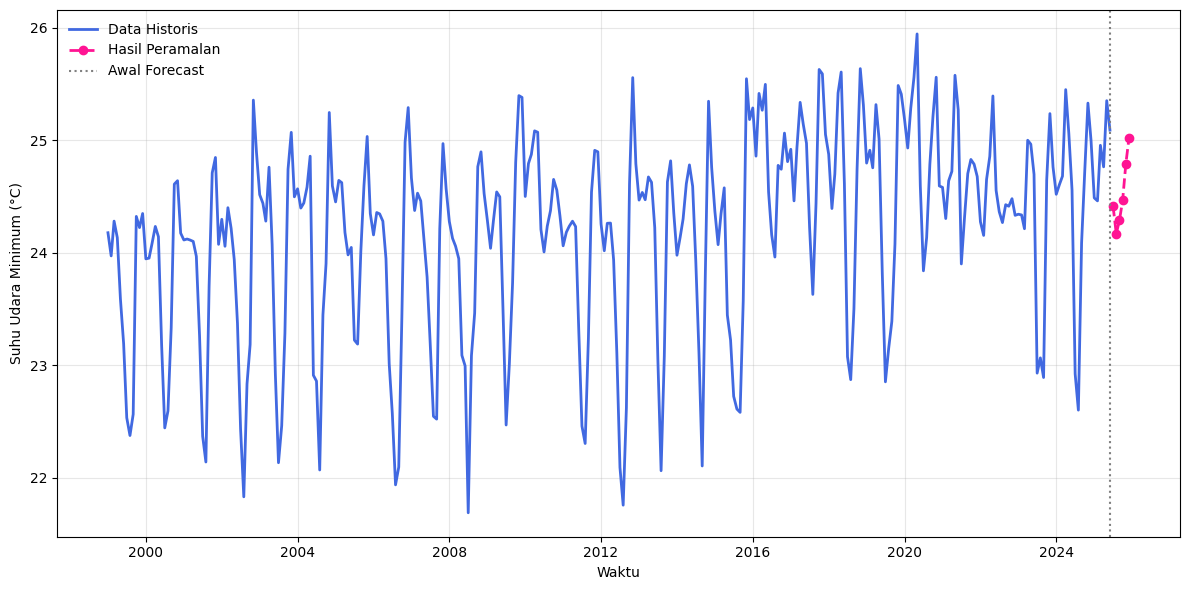

In [ ]:
# Visualisasi Hasil Peramalan
forecast_suhu = pd.DataFrame({
    'tanggal': forecast_data.index,
    'prediksi': forecast_data['Suhu']
})
forecast_suhu.set_index('tanggal', inplace = True)

historical_data_suhu = data[['Suhu']].copy()
combined_suhu = pd.concat([historical_data_suhu, forecast_suhu.rename(columns = {'prediksi': 'Suhu'})])

plt.figure(figsize = (12, 6))

plt.plot(
    historical_data_suhu.index,
    historical_data_suhu['Suhu'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_suhu.index,
    forecast_suhu['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.axvline(
    x = historical_data_suhu.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

plt.xlabel('Waktu')
plt.ylabel('Suhu Udara Minimum (°C)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()

plt.show()

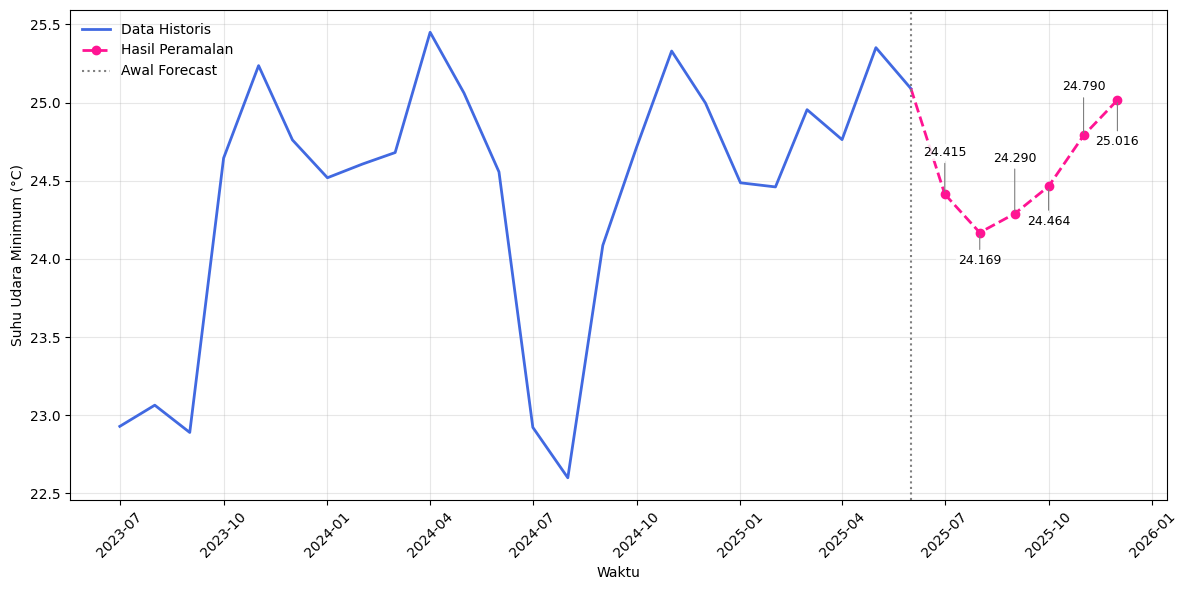

In [ ]:
# Visualisasi Hasil Peramalan
plt.style.use('default')

historical_tail_suhu = data[['Suhu']].tail(24).copy()

forecast_suhu = pd.DataFrame({
    'tanggal': forecast_data.index,
    'prediksi': forecast_data['Suhu']
})
forecast_suhu.set_index('tanggal', inplace = True)

plt.figure(figsize = (12, 6))

plt.plot(
    historical_tail_suhu.index,
    historical_tail_suhu['Suhu'],
    label = 'Data Historis',
    color = 'royalblue',
    linewidth = 2
)

plt.plot(
    forecast_suhu.index,
    forecast_suhu['prediksi'],
    label = 'Hasil Peramalan',
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2,
    marker = 'o'
)

plt.plot(
    [historical_tail_suhu.index[-1], forecast_suhu.index[0]],
    [historical_tail_suhu['Suhu'].iloc[-1], forecast_suhu['prediksi'].iloc[0]],
    color = 'deeppink',
    linestyle = '--',
    linewidth = 2
)

plt.axvline(
    x = historical_tail_suhu.index[-1],
    color = 'gray',
    linestyle = ':',
    label = 'Awal Forecast'
)

offsets = [
    (0, 30),
    (0, -20),
    (0, 40),
    (0, -25),
    (0, 35),
    (0, -30)
]

for (x, y), (dx, dy) in zip(zip(forecast_suhu.index, forecast_suhu['prediksi']), offsets):
    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = (dx, dy),
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        bbox = dict(facecolor = 'white', alpha = 0.85, edgecolor = 'none', pad = 1.2),
        arrowprops = dict(
            arrowstyle = '-',
            color = 'gray',
            lw = 0.8
        )
    )

plt.xlabel('Waktu')
plt.ylabel('Suhu Udara Minimum (°C)')
plt.xticks(rotation = 45)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

# TN10p

In [ ]:
# Data Historis
print("Data Historis (5 baris pertama dan terakhir):")
print(data.head())
print("\n...\n")
print(data.tail())
print(f"\nRentang data historis: {data.index[0]} hingga {data.index[-1]}")

Data Historis (5 baris pertama dan terakhir):
                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
1999-01-01  24.177419    30092.61419      40613.36      9725.40
1999-02-01  23.971429    33898.16893      40363.34      8823.81
1999-03-01  24.280645    32010.34290      40334.69      1194.58
1999-04-01  24.133333    36139.28767      39600.00     19013.41
1999-05-01  23.590323    38292.59323      39589.61     27711.09

...

                 Suhu  DPM Rata-rata  DPM Maksimum  DPM Minimum
Bulan                                                          
2025-02-01  24.460714    35262.12000      41519.75     12301.87
2025-03-01  24.954839    33148.25742      41275.54     18045.26
2025-04-01  24.763333    35864.13900      39617.05     23049.29
2025-05-01  25.351613    33211.00806      39594.77     18897.02
2025-06-01  25.090000    36222.82367      39486.35      2810.59

Rentang data historis: 1999-01-01 00:00:00 hingga 2

In [ ]:
# Membuat DataFrame dari Data Historis
data_historis = data.copy()
data_historis['Suhu'] = data_historis['Suhu']
data_historis['Year'] = data_historis.index.year
data_historis['Month'] = data_historis.index.month
data_historis['Type'] = 'Historis'

print(f"\nJumlah data historis: {len(data_historis)} bulan")


Jumlah data historis: 318 bulan


In [ ]:
# Membuat DataFrame dari Hasil Forecast
data_forecast = forecast_data[['Suhu']].copy()
data_forecast['Year'] = data_forecast.index.year
data_forecast['Month'] = data_forecast.index.month
data_forecast['Type'] = 'Forecast'

print(f"\nJumlah data forecast: {len(data_forecast)} bulan")


Jumlah data forecast: 6 bulan


In [ ]:
# Menggabungkan Data Historis dan Forecast
cols_to_keep = ['Suhu', 'Year', 'Month', 'Type']
data_historis = data_historis[cols_to_keep]
data_forecast = data_forecast[cols_to_keep]

data_gabungan = pd.concat([data_historis, data_forecast], axis = 0)

data_gabungan = data_gabungan.sort_index()

print("Data Gabungan (Historis + Forecast):")
print(f"Total data: {len(data_gabungan)} bulan")
print(f"Rentang waktu: {data_gabungan.index[0]} hingga {data_gabungan.index[-1]}")
print(f"\nBreakdown:")
print(f"- Data historis: {len(data_historis)} bulan")
print(f"- Data forecast: {len(data_forecast)} bulan")
print(f"- Total: {len(data_historis) + len(data_forecast)} bulan")

print("\n5 baris terakhir historis:")
print(data_historis.tail())

print("\n5 baris pertama forecast:")
print(data_forecast.head())

print("\n5 baris terakhir data gabungan:")
print(data_gabungan.tail())

Data Gabungan (Historis + Forecast):
Total data: 324 bulan
Rentang waktu: 1999-01-01 00:00:00 hingga 2025-12-01 00:00:00

Breakdown:
- Data historis: 318 bulan
- Data forecast: 6 bulan
- Total: 324 bulan

5 baris terakhir historis:
                 Suhu  Year  Month      Type
Bulan                                       
2025-02-01  24.460714  2025      2  Historis
2025-03-01  24.954839  2025      3  Historis
2025-04-01  24.763333  2025      4  Historis
2025-05-01  25.351613  2025      5  Historis
2025-06-01  25.090000  2025      6  Historis

5 baris pertama forecast:
                 Suhu  Year  Month      Type
2025-07-01  24.414608  2025      7  Forecast
2025-08-01  24.168613  2025      8  Forecast
2025-09-01  24.289698  2025      9  Forecast
2025-10-01  24.464279  2025     10  Forecast
2025-11-01  24.789825  2025     11  Forecast

5 baris terakhir data gabungan:
                 Suhu  Year  Month      Type
2025-08-01  24.168613  2025      8  Forecast
2025-09-01  24.289698  2025      

In [ ]:
# Persentil ke-10 per Tahun
p10_per_year = (
    data_gabungan
    .groupby('Year')['Suhu']
    .quantile(0.10)
    .reset_index()
    .rename(columns = {'Suhu': 'P10_Suhu'})
)

print("\nPersentil ke-10 (P10) Suhu tiap tahun:")
print(p10_per_year)


Persentil ke-10 (P10) Suhu tiap tahun:
    Year   P10_Suhu
0   1999  22.535366
1   2000  22.651527
2   2001  22.456968
3   2002  22.472366
4   2003  22.506828
5   2004  22.863258
6   2005  23.298387
7   2006  22.141097
8   2007  22.609677
9   2008  23.002387
10  2009  23.057376
11  2010  24.209548
12  2011  22.535591
13  2012  22.143290
14  2013  23.054452
15  2014  23.173871
16  2015  22.620968
17  2016  24.196258
18  2017  24.244323
19  2018  23.117108
20  2019  23.169645
21  2020  24.181269
22  2021  24.304827
23  2022  24.268387
24  2023  22.942581
25  2024  23.038989
26  2025  24.302189


In [ ]:
# Klasifikasi Bulan < Persentil ke-10
data_p10 = data_gabungan.merge(
    p10_per_year,
    on = 'Year',
    how = 'left'
)

data_p10['Below_P10'] = data_p10['Suhu'] < data_p10['P10_Suhu']

suhu_ekstrem_bawah = data_p10[data_p10['Below_P10']]

print("\nBulan dengan Suhu di Bawah Persentil ke-10 (TN10p):")
print(suhu_ekstrem_bawah[['Suhu', 'Year', 'Month', 'Type', 'P10_Suhu']])

print(f"\nJumlah kejadian suhu < Persentil ke-10: {len(suhu_ekstrem_bawah)} bulan")


Bulan dengan Suhu di Bawah Persentil ke-10 (TN10p):
          Suhu  Year  Month      Type   P10_Suhu
6    22.532258  1999      7  Historis  22.535366
7    22.374194  1999      8  Historis  22.535366
18   22.441935  2000      7  Historis  22.651527
19   22.593548  2000      8  Historis  22.651527
30   22.367742  2001      7  Historis  22.456968
31   22.138710  2001      8  Historis  22.456968
42   22.432258  2002      7  Historis  22.472366
43   21.829032  2002      8  Historis  22.472366
54   22.132258  2003      7  Historis  22.506828
55   22.461290  2003      8  Historis  22.506828
66   22.858065  2004      7  Historis  22.863258
67   22.067742  2004      8  Historis  22.863258
78   23.222581  2005      7  Historis  23.298387
79   23.187097  2005      8  Historis  23.298387
91   21.935484  2006      8  Historis  22.141097
92   22.093333  2006      9  Historis  22.141097
103  22.545161  2007      8  Historis  22.609677
104  22.520000  2007      9  Historis  22.609677
113  22.993333  

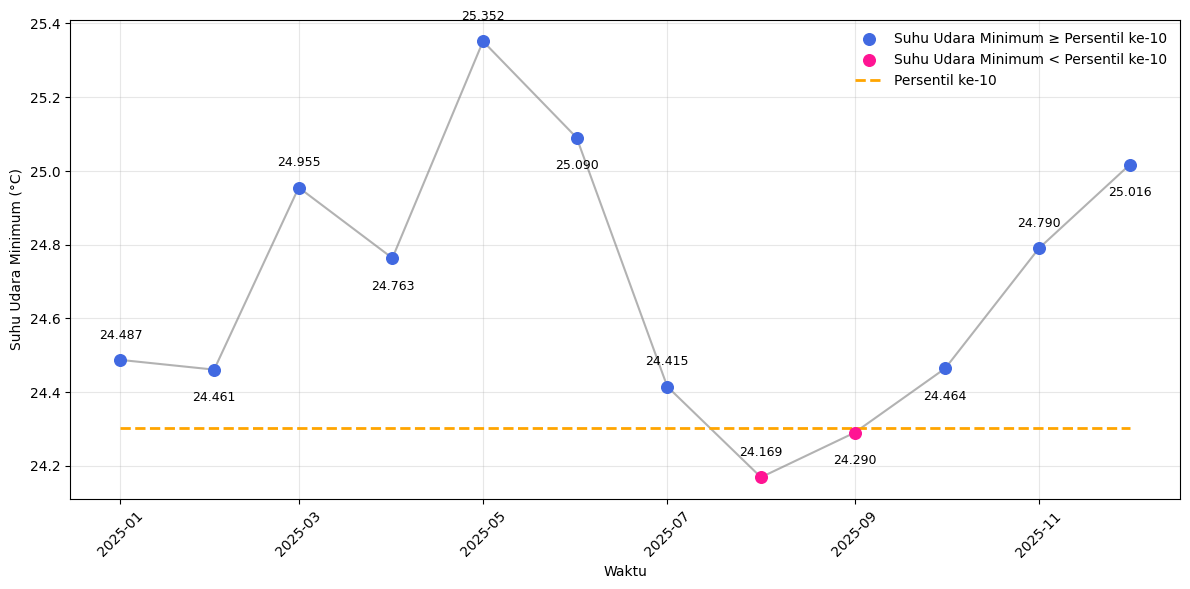

In [ ]:
# Visualisasi Suhu Udara Minimum Tahun 2025 + Peramalan + Persentil ke-10
historical_2025 = data.loc[data.index.year == 2025, ['Suhu']].copy()
historical_2025['Type'] = 'Historis'

forecast_2025 = forecast_data.loc[forecast_data.index.year == 2025, ['Suhu']].copy()
forecast_2025['Type'] = 'Forecast'

data_2025 = pd.concat([historical_2025, forecast_2025], axis = 0)
data_2025 = data_2025.sort_index()

data_2025 = data_2025[~data_2025.index.duplicated(keep = 'first')]

data_2025['P10_Suhu'] = data_2025['Suhu'].quantile(0.10)
data_2025['Below_P10'] = data_2025['Suhu'] < data_2025['P10_Suhu']

data_atas = data_2025[data_2025['Below_P10'] == False]
data_bawah = data_2025[data_2025['Below_P10'] == True]

plt.figure(figsize = (12, 6))

plt.plot(
    data_2025.index,
    data_2025['Suhu'],
    color = 'gray',
    linewidth = 1.5,
    alpha = 0.6
)

plt.scatter(
    data_atas.index,
    data_atas['Suhu'],
    color = 'royalblue',
    s = 70,
    label = 'Suhu Udara Minimum ≥ Persentil ke-10',
    zorder = 3
)

plt.scatter(
    data_bawah.index,
    data_bawah['Suhu'],
    color = 'deeppink',
    s = 70,
    label = 'Suhu Udara Minimum < Persentil ke-10',
    zorder = 3
)

plt.plot(
    data_2025.index,
    data_2025['P10_Suhu'],
    color = 'orange',
    linestyle = '--',
    linewidth = 2,
    label = 'Persentil ke-10'
)

for i, (x, y) in enumerate(zip(data_2025.index, data_2025['Suhu'])):
    if y < data_2025['P10_Suhu'].iloc[0]:
        xytext = (0, -20) if i % 2 == 0 else (0, 18)
    else:
        xytext = (0, 18) if i % 2 == 0 else (0, -20)

    plt.annotate(
        f'{y:.3f}',
        xy = (x, y),
        xytext = xytext,
        textcoords = 'offset points',
        ha = 'center',
        va = 'center',
        fontsize = 9,
        color = 'black'
    )

plt.gca().xaxis.set_major_formatter(DateFormatter('%Y-%m'))
plt.xticks(rotation = 45)

plt.xlabel('Waktu')
plt.ylabel('Suhu Udara Minimum (°C)')

plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()